#Data Preparation

In [ ]:
import os, zipfile, shutil, PIL
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

from tensorflow import keras
from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop

In [ ]:
!pip install -q kaggle

In [ ]:
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!chmod 600 /content/kaggle.json

In [ ]:
! KAGGLE_CONFIG_DIR=/content/ kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:06<00:00, 110MB/s]
100% 675M/675M [00:06<00:00, 114MB/s]


In [ ]:
local_zip = '/content/cell-images-for-detecting-malaria.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
BASE_DIR = '/content/cell_images/'

In [ ]:
def list_files(startpath):
  num_files = 0
  for root, dirs, files in os.walk(startpath):
    level = root.replace(startpath, '').count(os.sep)
    indent = ' ' * 2 * (level)
    num_files += len(files)
    print('{}{}/ {}'.format(indent, os.path.basename(root), (str(len(files)) + ' images' if len(files) > 0 else '')))

  return num_files


In [ ]:
list_files(BASE_DIR)

/ 
cell_images/ 
  Parasitized/ 13780 images
  Uninfected/ 13780 images
Parasitized/ 13780 images
Uninfected/ 13780 images


55120

In [ ]:
def read_files(startpath):
  image_files = []
  for dirname, dirnames, filenames in os.walk(startpath):
    for filename in filenames:
      image_files.append(os.path.join(dirname, filename))

  return image_files

In [ ]:
os.remove("/content/cell_images/Parasitized/Thumbs.db")
os.remove("/content/cell_images/Uninfected/Thumbs.db")
os.remove("/content/cell_images/cell_images/Parasitized/Thumbs.db")
os.remove("/content/cell_images/cell_images/Uninfected/Thumbs.db")

In [ ]:
full_dirs = read_files(BASE_DIR + "cell_images")
image_sizes = []
for file in full_dirs:
  image = PIL.Image.open(file)
  width, height = image.size
  image_sizes.append(f'{width}x{height}')

unique_sizes = set(image_sizes)

print(f'Size all images: {len(image_sizes)}')
print(f'Size unique images: {len(unique_sizes)}')
print(f'First 10 unique images: \n{list(unique_sizes)[:10]}')

Size all images: 27558
Size unique images: 1627
First 10 unique images: 
['157x124', '112x148', '91x121', '196x181', '229x133', '112x103', '118x94', '166x175', '91x112', '106x154']


#Data Preprocessing dan Data Splitting

In [ ]:
datagen = ImageDataGenerator(
  rescale=1./255,
  validation_split=0.2,
  zoom_range=0.2,
  shear_range=0.2,
  rotation_range=0.2
)

In [ ]:
training_generator = datagen.flow_from_directory(
  BASE_DIR + "cell_images",
  subset='training',
  target_size=(120,120),
  seed=42,
  batch_size=64,
  interpolation='nearest',
  class_mode='binary',
  classes=['Parasitized','Uninfected']
)

validation_generator = datagen.flow_from_directory(
  BASE_DIR + "cell_images",
  subset='validation',
  target_size=(120,120),
  seed=42,
  batch_size=64,
  interpolation='nearest',
  class_mode='binary',
  classes=['Parasitized','Uninfected']
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [ ]:
print(training_generator.class_indices)


{'Parasitized': 0, 'Uninfected': 1}


In [ ]:
parasitized_count = sum(training_generator.labels == 0)  # Jika 0 adalah indeks untuk 'Parasitized'
uninfected_count = sum(training_generator.labels == 1)  # Jika 1 adalah indeks untuk 'Uninfected'
print(f'Jumlah gambar Parasitized: {parasitized_count}')
print(f'Jumlah gambar Uninfected: {uninfected_count}')

Jumlah gambar Parasitized: 11024
Jumlah gambar Uninfected: 11024


#Modelling & Training

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(120, 120, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.6),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.4),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.summary()

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
)

class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if((logs.get('accuracy') > 0.91) and (logs.get('val_accuracy') > 0.91)):
      self.model.stop_training = True
      print("\nThe accuracy of the training set and the validation set has reached > 91%!")
callbacks = myCallback()

LR = 1e-4
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=LR),
              metrics=['accuracy'])

result = model.fit(
    training_generator,
    validation_data=validation_generator,
    epochs=25,
    steps_per_epoch=150,
    validation_steps=35,
    callbacks=[callbacks],
    verbose=1
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 118, 118, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 59, 59, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 57, 57, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,685,569 (14.06 MB)

 Trainable params: 3,685,569 (14.06 MB)

...

Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


150/150 ━━━━━━━━━━━━━━━━━━━━ 559s 4s/step - accuracy: 0.5511 - loss: 0.6853 - val_accuracy: 0.7326 - val_loss: 0.6239
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 552s 4s/step - accuracy: 0.6608 - loss: 0.6232 - val_accuracy: 0.7830 - val_loss: 0.5530
Epoch 3/25
 45/150 ━━━━━━━━━━━━━━━━━━━━ 5:51 3s/step - accuracy: 0.7212 - loss: 0.5793

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


150/150 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.7217 - loss: 0.5722 - val_accuracy: 0.8175 - val_loss: 0.5365
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 542s 4s/step - accuracy: 0.7639 - loss: 0.5061 - val_accuracy: 0.8679 - val_loss: 0.3572
Epoch 5/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 547s 4s/step - accuracy: 0.8668 - loss: 0.3364 - val_accuracy: 0.9013 - val_loss: 0.3089
Epoch 6/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8919 - loss: 0.2819 - val_accuracy: 0.9243 - val_loss: 0.2571
Epoch 7/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 567s 4s/step - accuracy: 0.9000 - loss: 0.2723 - val_accuracy: 0.9214 - val_loss: 0.2306
Epoch 8/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 530s 4s/step - accuracy: 0.9065 - loss: 0.2546 - val_accuracy: 0.9098 - val_loss: 0.2903
Epoch 9/25
 45/150 ━━━━━━━━━━━━━━━━━━━━ 5:54 3s/step - accuracy: 0.9163 - loss: 0.2426
The accuracy of the training set and the validation set has reached > 91%!
150/150 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9153 - loss: 0.2402

#Plot Accuracy & Loss

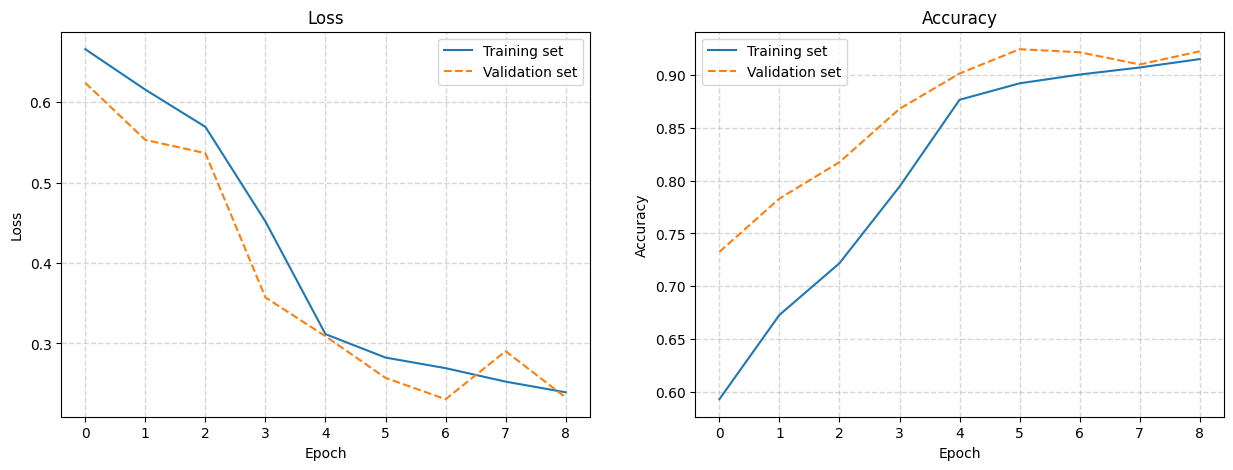

In [ ]:
loss = result.history['loss']
val_loss = result.history['val_loss']
acc = result.history['accuracy']
val_acc = result.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(loss, label='Training set')
plt.plot(val_loss, label='Validation set', linestyle='--')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.5)

plt.subplot(1, 2, 2)
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(acc, label='Training set')
plt.plot(val_acc, label='Validation set', linestyle='--')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.5)

plt.show()

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmplsc_6aix'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 120, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134006891452672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891455664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891455840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891458128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891455488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891460240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891459536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891462000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891452848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134006891456896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13400689145936

In [ ]:
with tf.io.gfile.GFile('model__v1.tflite', 'wb') as f:
  f.write(tflite_model)

In [ ]:
# Debug: Print raw output
print("Raw output array:", output_array)


Raw output array: [[0.02861584]]


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import tensorflow as tf

# Unggah gambar
uploaded = files.upload()

# Proses gambar yang diunggah
image_path = list(uploaded.keys())[0]
image = Image.open(image_path)
image.show()

# Ubah ukuran gambar menjadi (120, 120) sesuai dengan input model
image = image.resize((120, 120))

# Ubah gambar menjadi array dan skalakan nilai pikselnya
image_array = np.array(image) / 255.0

# Tambahkan dimensi untuk batch (1, 120, 120, 3)
image_array = np.expand_dims(image_array, axis=0)

# Konversi array gambar menjadi tipe data FLOAT32
image_array = image_array.astype(np.float32)

# Nama file model TFLite
TFLITE_MODEL = 'model__v1.tflite'

# Memuat model TFLite
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
interpreter.allocate_tensors()

# Mendapatkan detail input dan output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model TFLite berhasil dimuat.")

# Menetapkan input tensor
input_index = input_details[0]['index']
interpreter.set_tensor(input_index, image_array)

# Menjalankan inferensi
interpreter.invoke()

# Mendapatkan output tensor
output_index = output_details[0]['index']
output_array = interpreter.get_tensor(output_index)

# Debug: Print raw output
print("Raw output array:", output_array)

# Mendapatkan prediksi
predictions = output_array[0]
print("Predictions:", predictions)
probability = predictions[0]
if probability > 0.5:
    predicted_label = 'Uninfected'
else:
    predicted_label = 'Parasitized'

print(f'Prediksi kelas: {predictions[0]}')
print(f'Label prediksi: {predicted_label}')
print(f'Keyakinan: {probability}')


Saving C99P60ThinF_IMG_20150918_142334_cell_28.png to C99P60ThinF_IMG_20150918_142334_cell_28.png
Model TFLite berhasil dimuat.
Raw output array: [[0.00269729]]
Predictions: [0.00269729]
Prediksi kelas: 0.0026972934138029814
Label prediksi: Parasitized
Keyakinan: 0.0026972934138029814
